# IEEE-CIS — exploratory data analysis

Exploration only: no production logic lives here (all pipeline code is in `src/fraudops/`).
Covers the three questions that matter for the rest of the project:

1. **Class balance over time** — is fraud prevalence stable, and does the chronological split see different rates?
2. **Missingness** — which blocks of columns are sparse, and does the identity join leave most rows empty?
3. **Transaction amount over time** — do amounts drift, and do fraud amounts behave differently?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from fraudops.data.clock import sim_day
from fraudops.data.loader import load_joined

plt.rcParams["figure.dpi"] = 110
RAW = Path("../data/raw")

df = load_joined(RAW / "train_transaction.csv", RAW / "train_identity.csv")
day = sim_day(df["TransactionDT"])
df = df.assign(sim_day=day, sim_week=day // 7)
n_days = int(df["sim_day"].max()) + 1
print(
    f"{len(df):,} transactions | fraud rate {df['isFraud'].mean():.4f} | "
    f"{n_days} simulated days | identity coverage {df['has_identity'].mean():.3f}"
)

590,540 transactions | fraud rate 0.0350 | 183 simulated days | identity coverage 0.244


C:\Users\benbrahimmazen\AppData\Local\Temp\ipykernel_18784\832639974.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(sim_day=day, sim_week=day // 7)
C:\Users\benbrahimmazen\AppData\Local\Temp\ipykernel_18784\832639974.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(sim_day=day, sim_week=day // 7)


## 1. Class balance over time

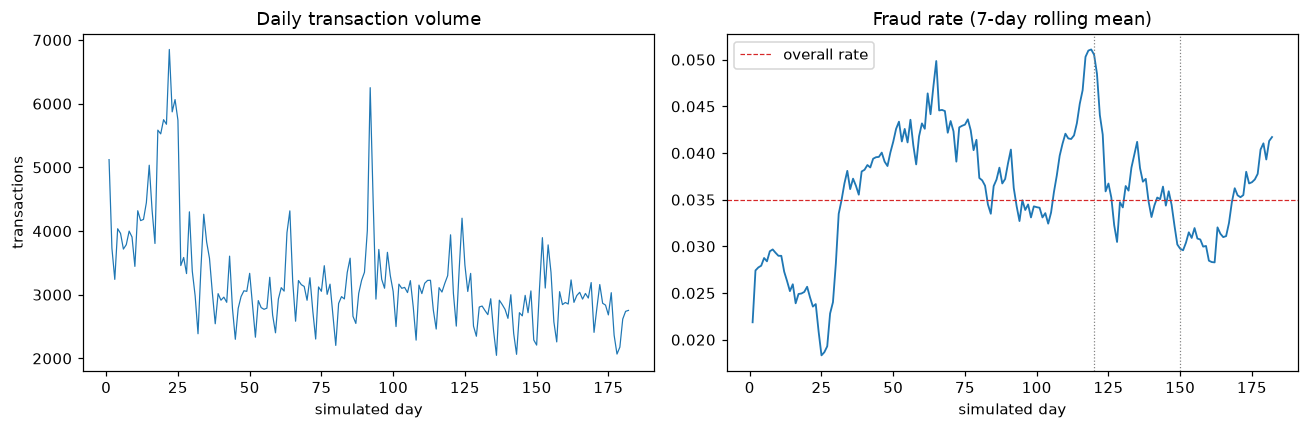

train       days   0-119 | 410,601 rows | rate 0.0351


validation  days 120-149 |  85,303 rows | rate 0.0347


stream      days 150-182 |  94,636 rows | rate 0.0347


In [2]:
daily = df.groupby("sim_day").agg(n=("isFraud", "size"), fraud_rate=("isFraud", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(daily.index, daily["n"], lw=0.8)
axes[0].set_title("Daily transaction volume")
axes[0].set_xlabel("simulated day")
axes[0].set_ylabel("transactions")

axes[1].plot(daily.index, daily["fraud_rate"].rolling(7, min_periods=1).mean(), lw=1.2)
axes[1].axhline(df["isFraud"].mean(), color="tab:red", ls="--", lw=0.8, label="overall rate")
for boundary in (120, 150):  # train|validation|stream boundaries from configs/splits.yaml
    axes[1].axvline(boundary, color="grey", ls=":", lw=0.8)
axes[1].set_title("Fraud rate (7-day rolling mean)")
axes[1].set_xlabel("simulated day")
axes[1].legend()
fig.tight_layout()
plt.show()

for name, lo, hi in (("train", 0, 120), ("validation", 120, 150), ("stream", 150, n_days)):
    part = df[(df["sim_day"] >= lo) & (df["sim_day"] < hi)]
    rate = part["isFraud"].mean()
    print(f"{name:<11} days {lo:>3}-{hi - 1:>3} | {len(part):>7,} rows | rate {rate:.4f}")

## 2. Missingness

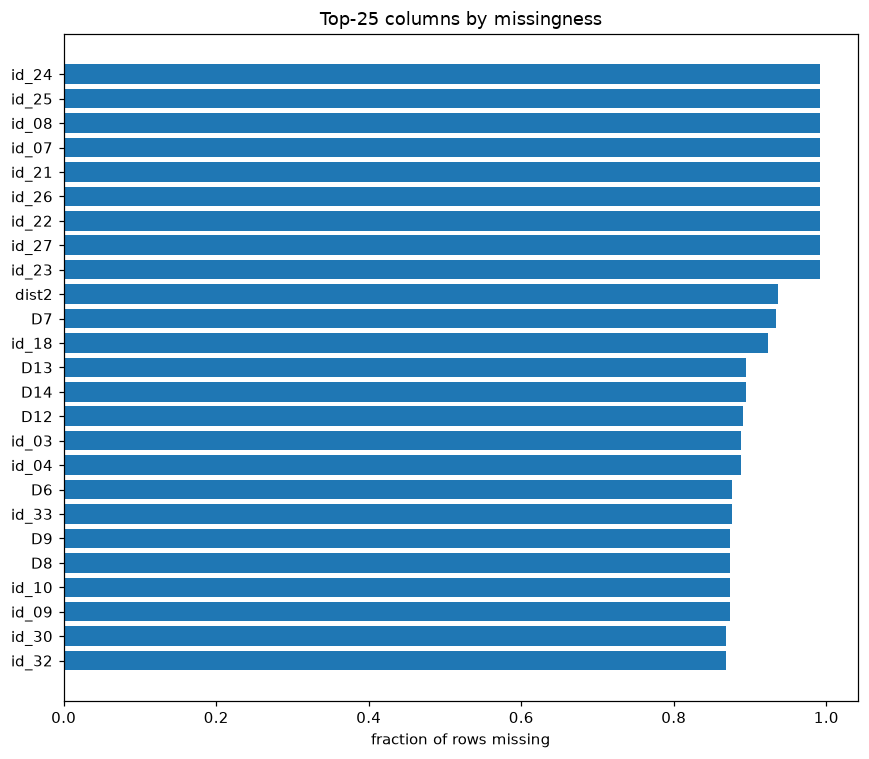

columns with >90% missing: 12 of 437
V-block: 339 cols, median missing 0.473
identity block absent for 0.756 of transactions


In [3]:
missing = df.isna().mean().sort_values(ascending=False)
top = missing.head(25)[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values)
ax.set_xlabel("fraction of rows missing")
ax.set_title("Top-25 columns by missingness")
fig.tight_layout()
plt.show()

v_cols = [c for c in df.columns if c.startswith("V")]
no_identity = 1 - df["has_identity"].mean()
print(f"columns with >90% missing: {(missing > 0.9).sum()} of {len(missing)}")
print(f"V-block: {len(v_cols)} cols, median missing {missing[v_cols].median():.3f}")
print(f"identity block absent for {no_identity:.3f} of transactions")

## 3. Transaction amount over time

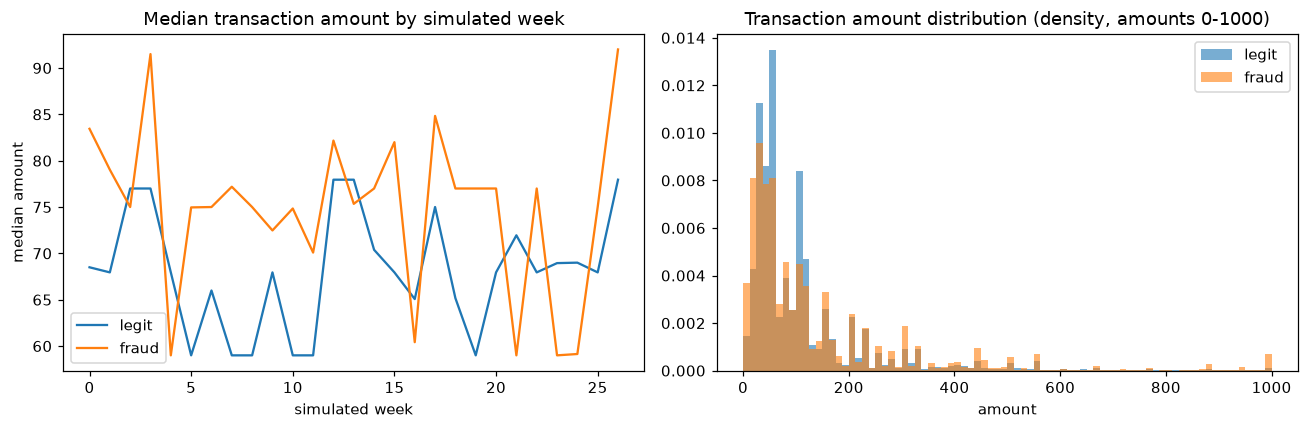

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [4]:
weekly = (
    df.groupby(["sim_week", "isFraud"])["TransactionAmt"]
    .median()
    .unstack()
    .rename(columns={0: "legit", 1: "fraud"})
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
weekly.plot(ax=axes[0])
axes[0].set_title("Median transaction amount by simulated week")
axes[0].set_xlabel("simulated week")
axes[0].set_ylabel("median amount")
axes[0].legend(title="")

for label, sub in (("legit", df[df["isFraud"] == 0]), ("fraud", df[df["isFraud"] == 1])):
    axes[1].hist(
        sub["TransactionAmt"], bins=80, range=(0, 1000), alpha=0.6, label=label, density=True
    )
axes[1].set_title("Transaction amount distribution (density, amounts 0-1000)")
axes[1].set_xlabel("amount")
axes[1].legend()
fig.tight_layout()
plt.show()

print(df.groupby("isFraud")["TransactionAmt"].describe().round(2).to_string())

## Observations

**Class balance.** Fraud prevalence is *not* stationary: the 7-day rolling rate
swings between roughly 1.5% and 6% over the six months (quarter averages run
2.9% → 4.1% → 3.8% → 3.4%). By construction the three split windows happen to
sit near the overall 3.5% (train 3.51%, validation 3.47%, stream 3.47%), but
the mid-period bump means a model trained on the earliest 120 days meets a
different fraud regime in validation and the stream — exactly the natural
drift the monitoring phase must observe rather than hide.

**Missingness.** Only 12 of 436 columns exceed 90% missing; the dominant
pattern is structural — the V-block (339 columns) has median missingness
0.47, and the identity block is absent for 75.7% of transactions because only
24.3% of transactions have an identity record at all. Missingness is treated
as signal: it passes through to LightGBM unimputed, and `has_identity`
carries the join structure explicitly.

**Amounts.** Fraud and legitimate amounts overlap heavily (medians 75.0 vs
68.5); fraud amounts lack the extreme tail of legitimate ones (max 5,191 vs
31,937). Amount alone is therefore a weak separator, and the weekly medians
move over time — another natural drift input. The cost framing stays
meaningful anyway: a missed fraud costs its own amount, so the rare large
fraud dominates expected loss.